# <span style="color: #1F1DB5;">SPRINT 14 - Métodos numéricos

# <span style="color: #1F1DB5;">Notebook 1 – Gradiente descendiente y función de costo

## <span style="color: #2826DE;">Objetivos de Aprendizaje

- Comprender la intuición del algoritmo de **Gradient Descent** como método de optimización utilizado en Machine Learning.
- Entender el concepto de **función de costo** y su importancia para evaluar el desempeño de un modelo.
- Explicar la **regla de actualización** y cómo el algoritmo ajusta los parámetros paso a paso.
- Visualizar la trayectoria del algoritmo sobre funciones de costo como **MSE (Mean Squared Error)** y **BCE (Binary Cross Entropy)** mediante gráficas.
- Implementar paso a paso el algoritmo de **Gradient Descent para regresión lineal con dos variables**, utilizando un dataset real.
- Interpretar cómo los cambios en el **learning rate** afectan la convergencia del algoritmo.

### <span style="color: #2772F2;">Agenda (2 horas)

| Tema | Duración |
|---|---|
¿Recordando cómo aprenden los modelos? | 10 min |
Intuición del Gradient Descent | 15 min |
Función de costo (MSE y BCE) | 15 min |
Regla de actualización y derivada (intuición) | 25 min |
Visualización del descenso de gradiente | 25 min |
Tips y buenas prácticas | 10 min |
Cierre + Kahoot + dudas | 20 min |


# <span style="color: #2826DE;">Requerimientos

Para esta sesión necesitaremos:

- Python 3.9+
- Jupyter Notebook / Google Colab
- Librerías:

```python
numpy
pandas
matplotlib
seaborn
scikit-learn
plotly

!pip install numpy pandas matplotlib seaborn scikit-learn plotly

## <span style="color: #2826DE;">❓ Pregunta Guía

### ¿Qué método de orientación usarías si tuvieses que bajar de una montaña con los ojos cerrados?

<img src="../Images/S14_DS_mountain.png" width="600">


Imagina que estás en una montaña completamente a oscuras.

Tu objetivo es llegar al punto más bajo del terreno, pero no puedes ver nada.

Lo único que puedes hacer es sentir la pendiente con tus pies y dar un paso en la dirección donde el suelo baja más.

Paso a paso, repites el proceso hasta llegar al punto más bajo.

Esta es exactamente la idea detrás de uno de los algoritmos más importantes de Machine Learning:

**Gradient Descent**

En esta sesión veremos cómo los modelos usan este método para encontrar los mejores parámetros minimizando una función de costo.


En esta sesión veremos cómo funciona el **Machine Learning**, una de las áreas más importantes de **Data Science**, y cómo los **algoritmos** pueden realmente **APRENDER** patrones a partir de los datos.

Hoy entrenaremos nuestros primeros modelos y veremos cómo una máquina puede aprender a **clasificar información**.

## <span style="color: #2826DE;">¿Recuerdas cómo aprenden los modelos? (10 mins)

En Machine Learning, los modelos no funcionan solos.

Para que un modelo funcione, necesita encontrar los mejores parámetros.

Por ejemplo, en una regresión lineal:

y = mx + b

El modelo debe encontrar los valores correctos de:

- m (pendiente)
- b (intersección)

Pero…

¿Cómo sabe el modelo cuáles son los mejores valores?

### <span style="color: #2772F2;">El problema como optimización

Podemos pensar el entrenamiento como un problema de optimización.

Queremos encontrar los parámetros que hacen que el error sea lo más pequeño posible.

Es decir:

Queremos minimizar una función.


Ejemplo:

Error = función(m, b)


Nuestro objetivo es encontrar:

m, b → que minimicen el error

### <span style="color: #2772F2;">Función de costo

La función que mide el error se llama:

### Función de costo

Esta función nos dice qué tan mal está el modelo.

Si el error es grande → el modelo es malo  
Si el error es pequeño → el modelo es bueno  


Ejemplo común:

Mean Squared Error (MSE)

### <span style="color: #2772F2;">Entrenar = minimizar la función de costo

Entrenar un modelo significa:

Buscar los parámetros que minimizan la función de costo.


Problema:

No sabemos dónde está el mínimo.

No podemos probar todos los valores posibles.

Necesitamos un método para encontrarlo.

### <span style="color: #2772F2;">Aquí entra Gradient Descent

Gradient Descent es un algoritmo que permite encontrar el mínimo de una función paso a paso.

La idea es:

- empezar en un punto
- ver hacia dónde baja la función
- moverse en esa dirección
- repetir hasta llegar al mínimo

En la siguiente sección veremos la intuición usando la analogía de la montaña.

<img src="../Images/S14_DS_Gradient_descent.gif" width="600">

## <span style="color: #2826DE;">Intuición del Gradient Descent (15 mins)

Recordemos la pregunta guía:

Estás en una montaña, no puedes ver, y quieres llegar al punto más bajo.

Lo único que puedes hacer es sentir la pendiente con tus pies.

Si el suelo baja hacia la derecha → te mueves a la derecha  
Si baja hacia la izquierda → te mueves a la izquierda  

Repites el proceso hasta llegar al punto más bajo.

Esta es la idea básica de **Gradient Descent**.

### <span style="color: #2772F2;">Pensando en una función

Imagina que tenemos una función como esta:

El eje horizontal representa el parámetro.

El eje vertical representa el error.

Queremos encontrar el punto donde el error es mínimo.

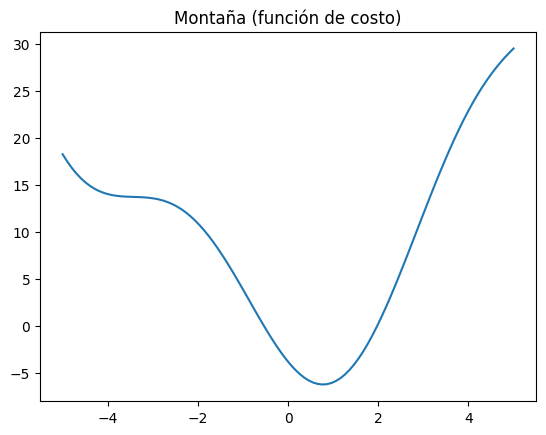

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 + 7*np.sin(x + 10)

x = np.linspace(-5,5,100)
y = f(x)

plt.plot(x,y)
plt.title("Montaña (función de costo)")
plt.show()

El punto más bajo de la curva es el mínimo.

Nuestro objetivo es llegar ahí.

### <span style="color: #2772F2;">Bajando paso a paso

Supongamos que empezamos en un punto aleatorio de la montaña:

No sabemos dónde está el mínimo.

Entonces hacemos lo siguiente:

1. Miramos la pendiente
2. Nos movemos hacia abajo
3. Repetimos

<img src="../Images/S14_DS_falling.gif" width="600">

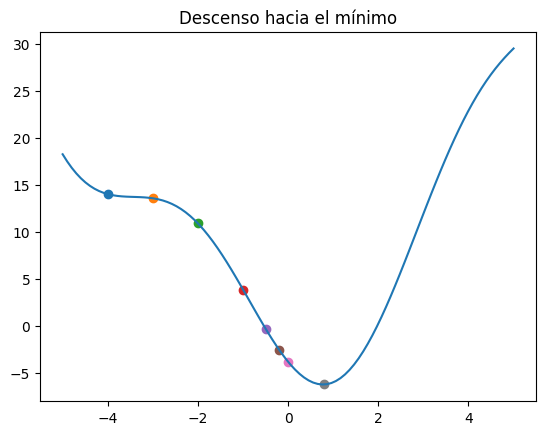

In [22]:
x = np.linspace(-5, 5, 100)
y = f(x)

plt.plot(x, y)

points = [-4, -3, -2, -1, -0.5, -0.2, 0, 0.8]

for p in points:
    plt.scatter(p, f(p))

plt.title("Descenso hacia el mínimo")
plt.show()

Cada punto representa un paso del algoritmo.

El algoritmo no salta al mínimo.

Va bajando poco a poco.

### Idea clave

Gradient Descent funciona así:

- Elegimos un punto inicial
- Calculamos la pendiente
- Nos movemos en la dirección contraria
- Repetimos hasta llegar al mínimo

En la siguiente sección veremos la regla matemática que permite hacer esto.

## <span style="color: #2826DE;">Función de costo (15 mins)

En Machine Learning, el objetivo no es solo hacer predicciones.

El objetivo es hacer predicciones correctas.

Para saber qué tan bueno es un modelo usamos una función que mide el error.

A esta función se le llama:

### <span style="color: #2772F2;"> Función de costo


La función de costo recibe los parámetros del modelo y devuelve el error.

### Ejemplo en regresión

En regresión lineal, el modelo es:

y = mx + b

Dependiendo de los valores de m y b, el error cambia.

Podemos pensar el error como una función:

Error = J(m, b)

Nuestro objetivo es encontrar los valores que minimicen J.

### <span style="color: #2772F2;">MSE — Mean Squared Error

Una de las funciones de costo más usadas es:

Mean Squared Error (MSE)

Mide el promedio del error al cuadrado.

Mientras más pequeño el MSE, mejor el modelo.

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Si el modelo predice bien → MSE pequeño  
Si predice mal → MSE grande

### <span style="color: #2772F2;">Visualizando una función de costo simple

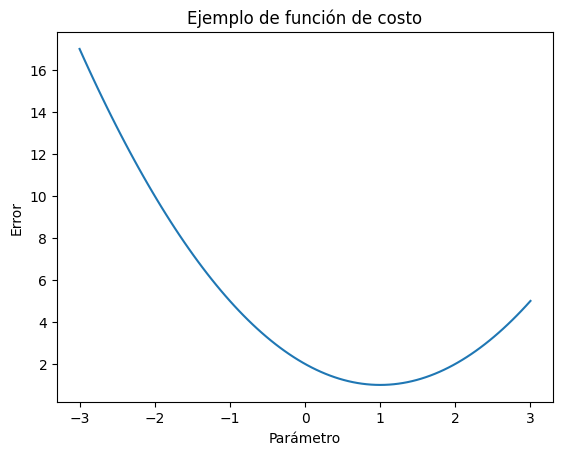

In [23]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 100)
y = (x - 1)**2 + 1

plt.plot(x, y)
plt.title("Ejemplo de función de costo")
plt.xlabel("Parámetro")
plt.ylabel("Error")
plt.show()

El mínimo de la función representa el mejor valor del parámetro.

### <span style="color: #2772F2;">BCE — Binary Cross Entropy

En problemas de clasificación usamos otra función de costo.

Se llama Binary Cross Entropy.

$$
BCE = -\frac{1}{n} \sum_{i=1}^{n} [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]
$$

Esta función se usa cuando queremos predecir probabilidades.

Por ejemplo:

- spam / no spam
- 0 / 1
- sí / no

### <span style="color: #2772F2;">Idea clave

Entrenar un modelo significa:

Minimizar la función de costo.

Para hacer eso usamos:

Gradient Descent

En la siguiente sección veremos cómo el algoritmo sabe hacia dónde moverse.

## <span style="color: #2826DE;">Regla de actualización y derivada (20 min) 

En la sección anterior vimos que queremos minimizar una función de costo.

Ahora la pregunta es:

¿Cómo sabe el algoritmo hacia dónde moverse?


La respuesta está en la pendiente de la función.

La pendiente nos dice hacia dónde la función crece y hacia dónde baja.

### <span style="color: #2772F2;">Pendiente (derivada) como dirección

Si la pendiente es positiva → la función sube  
Si la pendiente es negativa → la función baja  

Para llegar al mínimo debemos movernos en la dirección contraria a la pendiente.


Por eso usamos la derivada.

### <span style="color: #2772F2;">Regla de actualización

Gradient Descent actualiza el parámetro paso a paso usando la derivada.

$$
\theta = \theta - \alpha \nabla J(\theta)
$$

Donde:

- θ → parámetro
- α → learning rate
- ∇J(θ) → gradiente (derivada de la función de costo)

La idea es simple:

nuevo valor = valor actual − paso en dirección de bajada


### <span style="color: #2772F2;">Learning rate

El learning rate controla el tamaño del paso.

$$
\theta_{new} = \theta_{old} - \alpha \frac{dJ}{d\theta}
$$

Si el paso es muy grande → podemos saltar el mínimo  
Si el paso es muy pequeño → tardamos mucho  
Si el paso es correcto → convergemos

### <span style="color: #2772F2;">Ejemplo visual de distintos learning rates

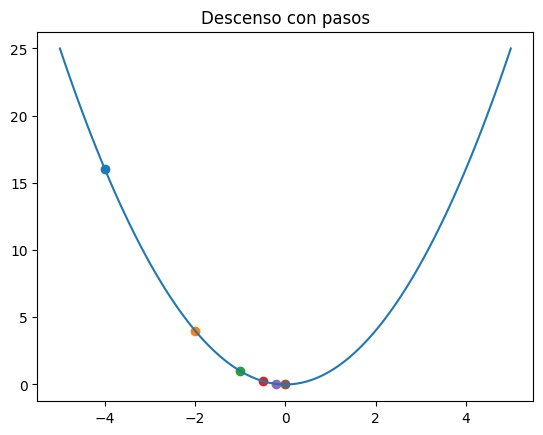

In [25]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = x**2

plt.plot(x, y)

points = [-4, -2, -1, -0.5, -0.2, 0]

for p in points:
    plt.scatter(p, p**2)

plt.title("Descenso con pasos")
plt.show()

En Machine Learning, elegir bien el learning rate es muy importante.

## <span style="color: #2826DE;">Visualización del descenso de gradiente (20 min)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

In [36]:
def f(x):
    return x**2 - 5*np.sin(x)

x = np.linspace(-6, 6, 200)
y = f(x)

def gradient(x):
    return 2*x - 5*np.cos(x)

def gradient_descent(x0, lr, steps):
    xs = [x0]
    x = x0
    for _ in range(steps):
        x = x - lr * gradient(x)
        xs.append(x)
    return xs

def plot_descent(x0, lr, steps):
    xs = gradient_descent(x0, lr, steps)
    x = np.linspace(-6, 6, 200)
    y = f(x)
    plt.figure(figsize=(6,4))
    plt.plot(x, y)
    for xi in xs:
        plt.scatter(xi, f(xi), s=80)
    plt.title(f"lr={lr} steps={steps}")
    plt.show()

In [ ]:
interact(
    plot_descent,
    x0=(-6,6,0.5),
    lr=(0.01,1,0.01),
    steps=(1,20,1)
)

interactive(children=(FloatSlider(value=0.0, description='x0', max=6.0, min=-6.0, step=0.5), FloatSlider(value…

<function __main__.plot_descent(x0, lr, steps)>

## Ejercicio

Prueba diferentes valores de learning rate:

- 0.01
- 0.1
- 0.5
- 1

Responde:

1. ¿Cuál converge más rápido?
2. ¿Cuál no converge?
3. ¿Cuál rebota?
4. ¿Por qué pasa eso?

Cambia la función por otra montaña más difícil

Ejemplo:
$$
f(x) = x^4 - 3x^3 + 2
$$

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
from IPython.display import clear_output
import time

np.random.seed(1)

X = np.linspace(0, 10, 50)
y = 2.5 * X + np.random.randn(50) * 2

def predict(beta, X):
    return beta * X

def mse(beta):
    y_pred = predict(beta, X)
    return np.mean((y - y_pred) ** 2)

def gradient(beta):
    y_pred = predict(beta, X)
    return -2 * np.mean(X * (y - y_pred))

def gradient_descent(beta0, lr, steps):
    beta = beta0
    history = [beta]
    for _ in range(steps):
        beta = beta - lr * gradient(beta)
        history.append(beta)
    return history

def show_gradient_descent(beta0):
    history = gradient_descent(beta0, lr=1, steps=0)
    beta = history[-1]
    betas = np.linspace(0,5,200)
    costs = [mse(b) for b in betas]
    fig, ax = plt.subplots(1,2, figsize=(13,5))

    # datos + regresión
    ax[0].scatter(X, y, label="Datos")
    y_pred = predict(beta, X)
    ax[0].plot(
        X,
        y_pred,
        color="red",
        label=f"Regresión β={beta:.2f}"
    )
    
    # líneas de error (residuales)
    for xi, yi, ypi in zip(X, y, y_pred):
        ax[0].plot(
            [xi, xi],
            [yi, ypi],
            linestyle="dotted"
        )
    ax[0].set_title("Datos y Línea de Regresión")
    ax[0].grid(True)
    ax[0].legend()

    # costo vs beta
    ax[1].plot(betas, costs, label="MSE(β)")
    ax[1].axvline(
        beta,
        linestyle="--",
        label=f"β actual = {beta:.2f}"
    )
    ax[1].scatter(
        beta,
        mse(beta),
        label=f"MSE = {mse(beta):.2f}"
    )
    ax[1].set_title("Función de costo")
    ax[1].grid(True)
    ax[1].legend()

    plt.show()

In [35]:
interact(
    show_gradient_descent,
    beta0=FloatSlider(value=0, min=0, max=5, step=0.1)
)

interactive(children=(FloatSlider(value=0.0, description='beta0', max=5.0), Output()), _dom_classes=('widget-i…

<function __main__.show_gradient_descent(beta0)>

## <span style="color: #2826DE;">Tips y buenas prácticas (10 mins)


Gradient Descent es un algoritmo muy poderoso, pero también es sensible a varios factores.

Estas son algunas buenas prácticas que debes seguir cuando trabajes con métodos de optimización.


### ✔ Elegir bien el learning rate

Si el learning rate es muy grande:

- el algoritmo puede divergir
- puede saltar el mínimo

Si es muy pequeño:

- el entrenamiento será muy lento

Siempre prueba distintos valores.


### ✔ Escalar o normalizar los datos

Cuando las variables tienen escalas muy distintas, Gradient Descent puede fallar.

Ejemplo:

- Edad → 20–60
- Ingreso → 1000–100000

Esto hace que la función de costo sea difícil de optimizar.

Por eso muchas veces usamos:

- Normalización
- Estandarización


### ✔ Revisar la función de costo durante el entrenamiento

Es buena práctica guardar el error en cada iteración.

Si el error baja → todo va bien  
Si el error sube → el learning rate puede ser muy grande  


### ✔ No usar demasiadas iteraciones sin revisar

Más iteraciones no siempre significa mejor modelo.

Puede haber:

- overfitting
- pérdida de tiempo
- inestabilidad


### ✔ Entender antes de usar librerías

Librerías como sklearn, tensorflow o pytorch usan optimización internamente.

Si entiendes Gradient Descent, entenderás mejor:

- regresión
- redes neuronales
- deep learning
- optimización


### ✔ Idea clave del Sprint

Entrenar un modelo = minimizar una función de costo

Gradient Descent es uno de los métodos más importantes para lograrlo.

## <span style="color: #2826DE;">Cierre + Kahoot (20 mins)</span>

En esta sesión estudiamos uno de los algoritmos más importantes en Machine Learning y Métodos Numéricos.

Aprendimos:

- Qué es una función de costo
- Cómo funciona Gradient Descent
- Qué es la regla de actualización
- Qué es el learning rate
- Cómo minimizar una función
- Por qué la optimización es clave en Machine Learning

Gradient Descent se usa en:

- Regresión lineal
- Regresión logística
- Redes neuronales
- Deep Learning
- Optimización numérica

En el siguiente notebook continuaremos aplicando estos conceptos en modelos más complejos.


Ahora vamos a hacer un Kahoot rápido para reforzar ideas.

Kahoot – Preguntas sugeridas


1️⃣ ¿Cuál es el objetivo de Gradient Descent?

- Maximizar el error  
- Minimizar la función de costo ✅  
- Dibujar gráficas  
- Normalizar datos  



2️⃣ ¿Qué representa la función de costo?

- El tamaño del dataset  
- El error del modelo ✅  
- El número de variables  
- El learning rate  



3️⃣ ¿Qué ocurre si el learning rate es demasiado grande?

- El modelo converge más rápido  
- El algoritmo puede divergir ✅  
- El error siempre baja  
- No pasa nada  



4️⃣ ¿Qué ocurre si el learning rate es muy pequeño?

- El entrenamiento es más lento ✅  
- El modelo falla siempre  
- El error aumenta  
- No afecta el resultado  



5️⃣ ¿Qué significa overfitting?

- El modelo aprende demasiado los datos de entrenamiento ✅  
- El modelo no aprende nada  
- El dataset es pequeño  
- El learning rate es grande  



6️⃣ ¿Para qué se usa Gradient Descent en Machine Learning?

- Para dividir datasets  
- Para optimizar parámetros del modelo ✅  
- Para graficar datos  
- Para cargar archivos  



7️⃣ ¿Qué indica que Gradient Descent está funcionando correctamente?

- La función de costo disminuye ✅  
- La función de costo aumenta  
- El dataset cambia  
- El modelo se detiene